# Local Embedding
-----------------

Following the methodlogy presented in:

https://pubs.acs.org/doi/10.1021/acs.jctc.8b01244


## Additional Software
----------------------

This example uses the freely available [embeddingAFQMC](https://github.com/bkesk/embeddingAFQMC) Python package
which, among other things, provides tools to analyze the locality of a set of orbitals.

## O adsorption on $H_{20}$ chain
---------------------------------

In [1]:
# Some setup
from pathlib import Path
from tutorial_utils import run_afqmc, get_scratch_dir

# from embeddingAFQMC
from embedding.orbital.assign import euclid_nd, gen_orbital_stats, print_stats

# For you TODO: set a scratch directory for the files that will be generated
home = Path.home()
scratch_dir = get_scratch_dir("08_local_embedding", home / ".scratch")

Hartree = 27.211407953 # eV
Bohr = 0.529177        # Angstrom

MPI_TASKS = 64

### Automate the AFQMC
----------------------

We can automate the local embedding workflow, for a given O atom hieght, $h$, and localization radii $R_o$, and $R_v$, using a Python function. The workflow consists of the following steps.


1. define the atomic positions
2. run ROHF to obtain both a trial wavefunction, and a basis
3. unitarily localize the set of ROHF orbitals using so-called "split localation". This can be done by partitioning the ROHF orbitals into the following sets, and localizing each set separately via Foster-Boys localization for example).
    - energetic core orbitals (no need to localize, we will freeze these no mater what)
    - occupied orbitals (including singly-occupied orbitals here; however, it is also possible to partition the singly-occupied orbitals from the doubly-occupied orbitals)
    - virtual orbitals
4. Select active orbitals using the $R_o$ and $R_v$ localization radii which apply to the occupied and virtual orbitals, respectively. An orbital is included in the active space if its centroid is localized within the applicable localization radius. Here, we use the 2-dimensional projection of the orbital centroid positions onto the $xy$-plane instead of the full 3-dimensional position.
5. perform a frozen core transformation on the many-body Hamiltonian based on the chosen active / inactive orbitals, and save the effective Hamiltonian to a SAFIRE HDF5 input file.
6. Write the ROHF determinant to the SAFIRE HDF5 format to use as a trial wavefunction.
7. Generate the json input file for SAFIRE
8. run AFQMC using SAFIRE
9. Compute the average AFQMC energy using afqmctools's analysis tooling

See the codeblock below.

In [2]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
from pyscf import gto, scf, lo

from afqmctools.utils.pyscf_utils import load_from_pyscf_chk_mol
from afqmctools.hamiltonian.mol import write_hamil_mol
from afqmctools.wavefunction.mol import write_wfn
from afqmctools.inputs.from_hdf import write_json
from stats.scalar_dat import analyze_scalar_data

from tutorial_utils import run_afqmc, get_scratch_dir


# custom metric to take the projection of the orbital position onto the xy plane
def euclid_2d(r1, r2):
    """
    Return the 2D Euclidean distance between two points r1 and r2, ignoring coordinates beyond the first two dimensions.
    """
    return euclid_nd(r1[:2], r2[:2])

def get_afqmc_energy(h, Ro=np.inf, Rv=np.inf, N_energetic_core=0, rhf_guess_rdm=None):
    # 1. generate underlying CMO basis
    # run initial HF calculation to generate basis

    local_scratch = scratch_dir / f"h={h:5.5f}"
    local_scratch.mkdir(exist_ok=True)
    atom_chkfile = local_scratch / f"rhf_h={h:5.5f}.chk"

    def get_atomic_positions(h):
        """
        h is input in Bohr, but needs to be converted to angstrom
        """

        return f"""O 0.000000 0.0 {h*Bohr}
                H -0.4704240745 0.0 0.0
                H 0.4704240745 0.0 0.0
                H 1.4112722235 0.0 0.0
                H 2.3521203725 0.0 0.0
                H 3.2929685215 0.0 0.0
                H 4.2338166705 0.0 0.0
                H 5.1746648195 0.0 0.0
                H 6.1155129685 0.0 0.0
                H 7.0563611175 0.0 0.0
                H 7.9972092665 0.0 0.0
                H 8.9380574155 0.0 0.0
                H 9.8789055645 0.0 0.0
                H 10.8197537135 0.0 0.0
                H 11.7606018625 0.0 0.0
                H 12.7014500115 0.0 0.0
                H 13.6422981605 0.0 0.0
                H 14.5831463095 0.0 0.0
                H 15.5239944585 0.0 0.0
                H 16.4648426075 0.0 0.0
                H 17.4056907565 0.0 0.0"""

    mol = gto.M(
        basis = 'ccpvdz',
        atom=get_atomic_positions(h),
        spin=0,
        verbose=3
    )

    # run HF
    mf = scf.RHF(mol).newton()
    mf.chkfile = atom_chkfile
    # it turns out to be helpful to initialize each HF calculation from the final solution of the
    # previous geometry
    dm0 = rhf_guess_rdm if rhf_guess_rdm is not None else None
    mf.kernel(dm0)

    # perform stability analysis - see PySCF example:
    # https://github.com/pyscf/pyscf.github.io/blob/master/examples/scf/17-stability.py
    mo1 = mf.stability()[0]
    dm1 = mf.make_rdm1(mo1, mf.mo_occ)
    mf = mf.run(dm1)
    mf.stability()
    Erhf = mf.kernel()

    rhf_rdm = mf.make_rdm1()

    # 2. generate a local basis
    # remove energetic core first - we will typically freeze these no matter what!
    core_orbitals =  mf.mo_coeff[:,:N_energetic_core]
    fb_core = lo.Boys(mol, core_orbitals)
    core_orbitals = fb_core.kernel()

    # foster-boys localization - occupied
    occ_orbitals = mf.mo_coeff[:,N_energetic_core:][:,mf.mo_occ[N_energetic_core:]>0]
    fb_occ = lo.Boys(mol, occ_orbitals)
    fb_occ_orbitals = fb_occ.kernel()

    # foster-boys localization - virtual
    virt_orbitals = mf.mo_coeff[:,N_energetic_core:][:,mf.mo_occ[N_energetic_core:]==0]
    fb_virt = lo.Boys(mol, virt_orbitals)
    fb_virt_orbitals = fb_virt.kernel()

    # 3. select active local orbitals
    core_stats = gen_orbital_stats(mol, core_orbitals, metric=euclid_2d)
    print_stats(core_stats)

    occ_stats_gen = gen_orbital_stats(mol, fb_occ_orbitals, metric=euclid_2d)
    occ_stats = sorted(occ_stats_gen, reverse=True)
    print_stats(occ_stats)

    virt_stats_gen = gen_orbital_stats(mol, fb_virt_orbitals, metric=euclid_2d)
    virt_stats = sorted(virt_stats_gen)
    print_stats(virt_stats)

    occ_sorted_indices = [ o.index for o in occ_stats ] # occ_stats is already sorted by distance!
    virt_sorted_indices = [ o.index for o in virt_stats ]
    print(occ_sorted_indices)
    print(virt_sorted_indices)

    local_basis = np.concatenate((core_orbitals, fb_occ_orbitals[:,occ_sorted_indices], fb_virt_orbitals[:,virt_sorted_indices]), axis=1)

    # select active orbitals

    # convert to orbital counts
    Ncore = sum( [1 for o in occ_stats if o.distance > Ro] ) + N_energetic_core
    N_active_occ = max(mol.nelec) - Ncore
    N_active_virt = sum( [1 for o in virt_stats if o.distance <= Rv] ) # this is the number of *active* virtuals

    ncas = N_active_occ + N_active_virt

    print(f"Ncore = {Ncore}")
    print(f"N_active_occ = {N_active_occ}")
    print(f"N_active_virt = {N_active_virt}")
    print(f"ncas = {ncas}")

    # 4. build and save the Hamiltonian
    # generate the Frozen Core Hamiltonian + save for AFQMC

    afqmc_hamil_file = local_scratch / "local_embedding_H.h5"

    scf_data = load_from_pyscf_chk_mol(
        chkfile = atom_chkfile
    )

    # edit the orbitals!
    scf_data["mo_coeff"] = local_basis

    write_hamil_mol(
        scf_data,
        cas=(2*(N_active_occ),ncas),
        hamil_file = afqmc_hamil_file,
        chol_cut = 1e-5,
        verbose=False
    )

    # 5. Write the trial wavefunction

    # write the trial wavefunction
    afqmc_wfn_file = local_scratch / "active_space_rhf_wfn.h5"

    active_det_up = np.eye(ncas,N_active_occ)
    wfn = ( np.array([1.0]), np.array([active_det_up]))
    nelec_active = (N_active_occ,N_active_occ)

    write_wfn(
        afqmc_wfn_file,
        wfn,
        walker_type='closed',
        nelec=nelec_active,
        norb=ncas,
        verbose=False
    )

    # 6. write json input file
    execute_options = {
        "timestep": 0.01,
        "steps": 10000,
        "population_control_interval" : 10,
        "measure_interval_multiplier": 1, # will measure at interval of `measure_interval_multiplier*population_control_interval`
        "walker_ortho_interval" : 10,
        "n_walkers_per_mpi_task": 20,
        "seed" : 42,
        "walker_set": {
            "walker_type": "COLLINEAR"
        },
    }
    write_json(
        local_scratch / "afqmc.json",
        fwfn0=afqmc_wfn_file,
        fham0=afqmc_hamil_file,
        exec_opts=execute_options
    )

    # 7. run AFQMC
    # run the AFQMC calculation...
    run_afqmc(
        run_dir=local_scratch,
        run_mode="local_cpu",
        timeout_mins=100,
        input_file="afqmc.json",
        np=MPI_TASKS,             # number of MPI tasks
        output_file="afqmc.out"   # optionally include output here by setting to None
    )

    # 8. analyze results
    settings = dict(
        fname = local_scratch/"qmc.s000.scalar.dat",
        xaxis = "time",
        nequil = 10,
        trace = True
    )

    return *analyze_scalar_data(settings),Erhf,rhf_rdm


## AFQMC Potential Energy Curve
-------------------------------

Let's use the function that we defined to compute $E[h]$ for $(R_o,R_v) = (3.8,6.2)$ Bohr.

converged SCF energy = -85.5053939255339


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.505393925573


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.5053939255739


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053262     0.230786 (-1.755907e-06,-2.395802e-19,+1.246612e+00)     0.000002
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    9     4.054194     2.013503 (+3.189972e+01,+3.461672e-17,-1.473432e-05)    31.899723
    4     4.759694     2.181672 (+2.841417e+01,-1.263729e-17,-2.199262e-05)    28.414168
    7     5.196931     2.279678 (+2.489359e+01,-1.464649e-18,-3.612815e-05)    24.893591
   12     5.429386     2.330104 (+2.136374e+01,-8.291747e-18,-6.304532e-05)    21.363745
    2     5.505702     2.346423 (+1.783085e+01,-2.022650e-17,-1.227262e-04)    17.830846
    6     5.436060     2.331536 (+1.429894e+01,-1.955700e-17,-2.674803e-04)    14.298937
    3     5.210270     2.282602 (+1.077245e+01,-8.814076e-17,-7.167153e-04)    10.772448
   11     4.780149     2.186355 (+7.258739e+00,-9.268683e-16,-2.448263e-03)     7.258739
   10     4.027956   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 488.817101 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=1.24700/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           



AFQMC Energy   -85.752109 +/-   0.000572 5.51 10.0/100.0


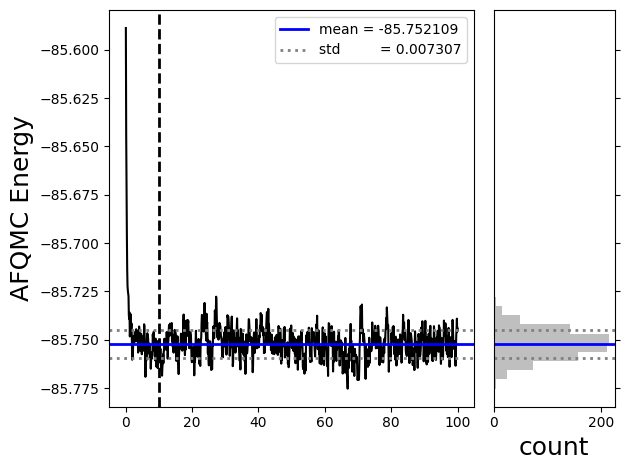

h = 1.247
E = -2333.435610094613 eV
dE = 0.015558532054812273 eV
E_rhf = -2326.7221562907603 eV
correlation E = -6.713453803852336

WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.5465397825277


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.5465397825336


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.5465397825336


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053218     0.230689 (-5.301149e-06,-8.025983e-19,+1.435669e+00)     0.000005
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    8     4.057308     2.014276 (+3.189737e+01,+1.017216e-15,-1.213863e-05)    31.897373
    3     4.767516     2.183464 (+2.841006e+01,+2.962124e-15,-1.427223e-05)    28.410063
    7     5.209544     2.282443 (+2.488771e+01,+6.740689e-15,-1.933178e-05)    24.887709
    2     5.447800     2.334052 (+2.135594e+01,+1.821774e-14,-2.909198e-05)    21.355940
    4     5.531591     2.351934 (+1.782087e+01,+5.225323e-14,-5.430842e-05)    17.820875
   10     5.472044     2.339240 (+1.428642e+01,+1.725514e-13,-1.244752e-04)    14.286418
   11     5.260654     2.293612 (+1.075676e+01,+7.287330e-13,-3.948366e-04)    10.756756
    6     4.852103     2.202749 (+7.238793e+00,+4.759644e-12,-1.619263e-03)     7.238793
    1     4.126713   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 484.893963 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=1.43600/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -85.800444 +/-   0.000753 7.99 10.0/100.0


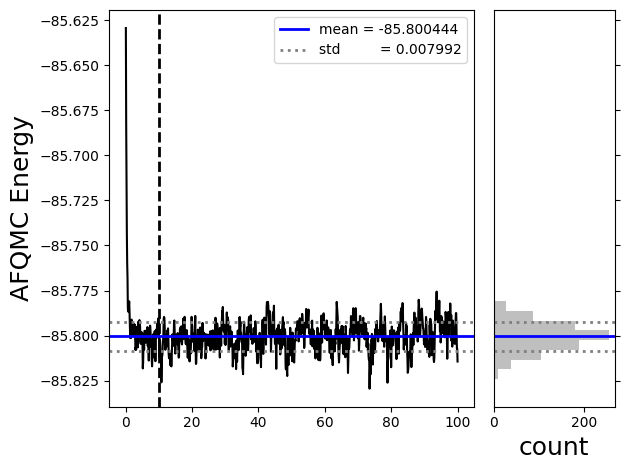

h = 1.436
E = -2334.750887306154 eV
dE = 0.020485172238992592 eV
E_rhf = -2327.8417929900666 eV
correlation E = -6.909094316086881



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.5324121334321


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



...

<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.5324121335303


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053159     0.230562 (-1.135912e-05,+1.011693e-19,+1.813763e+00)     0.000011
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    8     4.063600     2.015837 (+3.188955e+01,+3.536132e-13,+2.486574e-07)    31.889545
    3     4.785249     2.187521 (+2.839648e+01,+3.438724e-13,+1.873374e-05)    28.396478
    2     5.237777     2.288619 (+2.486838e+01,-1.681431e-13,+5.010098e-05)    24.868380
   11     5.488144     2.342679 (+2.133051e+01,-1.998848e-12,+1.091758e-04)    21.330506
   12     5.586870     2.363656 (+1.778871e+01,-8.108619e-12,+2.213423e-04)    17.788709
    1     5.546890     2.355184 (+1.424653e+01,-2.973702e-11,+4.487958e-04)    14.246535
    4     5.362288     2.315662 (+1.070757e+01,-1.567511e-10,+8.919182e-04)    10.707565
    7     4.992040     2.234287 (+7.177561e+00,-8.196081e-10,+1.687523e-03)     7.177561
   10     4.301812   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 486.240392 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=1.81400/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -85.800266 +/-   0.000860 6.66 10.0/100.0


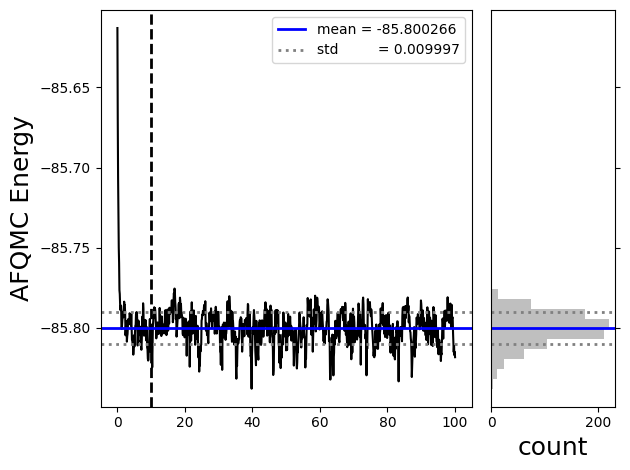

h = 1.814
E = -2334.7460462100325 eV
dE = 0.023397974977933625 eV
E_rhf = -2327.4573597696212 eV
correlation E = -7.28868644041125

WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4604797785581


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4604797785773


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.4604797785784


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053124     0.230485 (-1.238986e-05,+5.269070e-20,+2.380861e+00)     0.000012
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    7     4.069236     2.017235 (+3.187609e+01,-2.210991e-16,+2.021675e-05)    31.876090
   11     4.805070     2.192047 (+2.837324e+01,+1.932326e-14,+6.886318e-05)    28.373242
    6     5.268727     2.295371 (+2.483552e+01,-7.982462e-14,+1.534403e-04)    24.835519
   12     5.531028     2.351814 (+2.128757e+01,-4.029294e-13,+3.128964e-04)    21.287567
    1     5.643503     2.375606 (+1.773486e+01,-9.009547e-13,+6.241160e-04)    17.734860
   10     5.621313     2.370931 (+1.418043e+01,-2.847246e-12,+1.282043e-03)    14.180434
    4     5.460880     2.336852 (+1.062694e+01,-1.007424e-11,+2.757765e-03)    10.626944
    2     5.129074     2.264746 (+7.077978e+00,-6.615140e-11,+6.501474e-03)     7.077978
    3     4.507628   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 482.977592 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=2.38100/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -85.730813 +/-   0.000837 6.20 10.0/100.0


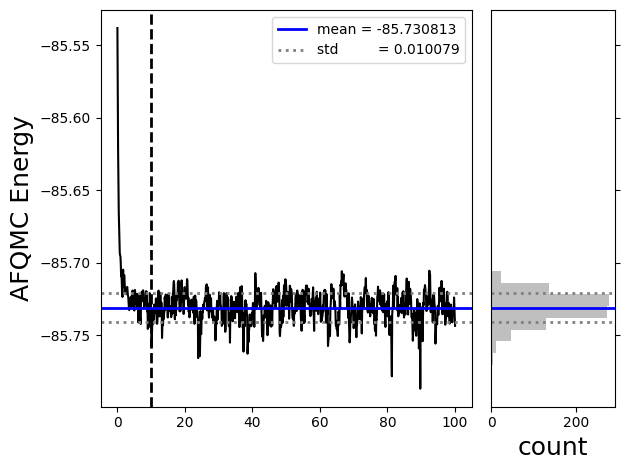

h = 2.381
E = -2332.856138882291 eV
dE = 0.02276615085720071 eV
E_rhf = -2325.4999791140035 eV
correlation E = -7.356159768287359

WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4114731847966


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4114731848101


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.41147318481


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053112     0.230460 (-3.893197e-06,-2.137492e-19,+3.325954e+00)     0.000004
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    7     4.074913     2.018641 (+3.187499e+01,-2.182590e-17,+2.330455e-05)    31.874990
   11     4.817517     2.194884 (+2.837124e+01,+1.820992e-18,+6.834198e-05)    28.371239
    6     5.289133     2.299811 (+2.483255e+01,-1.838012e-17,+1.467361e-04)    24.832549
   12     5.561895     2.358367 (+2.128348e+01,+1.309417e-17,+2.933560e-04)    21.283483
    1     5.688211     2.384997 (+1.772943e+01,-1.331202e-17,+5.769058e-04)    17.729427
   10     5.685990     2.384531 (+1.417325e+01,+5.409647e-17,+1.168745e-03)    14.173252
    4     5.555022     2.356909 (+1.061723e+01,+4.171485e-17,+2.482400e-03)    10.617229
    2     5.275322     2.296807 (+7.063637e+00,-4.459074e-17,+5.746093e-03)     7.063637
    3     4.784535   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 481.832421 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=3.32600/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -85.663440 +/-   0.000699 5.51 10.0/100.0


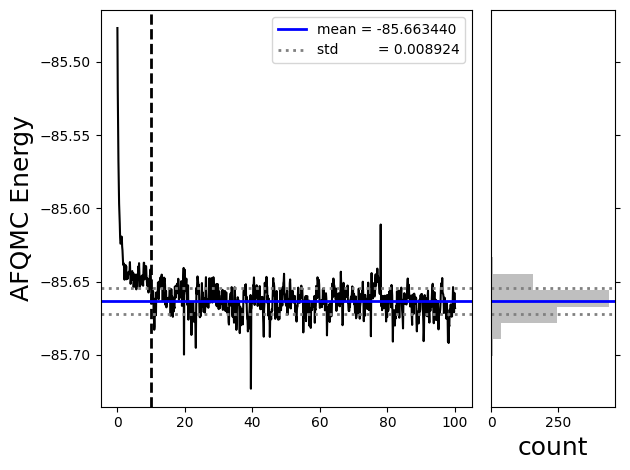

h = 3.326
E = -2331.0228214173335 eV
dE = 0.019007514077295014 eV
E_rhf = -2324.166440698586 eV
correlation E = -6.856380718747439

WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4032840075333


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis



WARN: Newton solver expects mo_coeff with mo_occ as initial guess but mo_occ is not found in the arguments.
      The given argument is treated as density matrix.



converged SCF energy = -85.4032840075908


<class 'pyscf.soscf.newton_ah.SecondOrderRHF'> wavefunction is stable in the internal stability analysis


converged SCF energy = -85.4032840075917


    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
    0     0.053110     0.230457 (-1.275664e-06,-5.517415e-19,+3.892979e+00)     0.000001
    i         mu_2      sigma_2              Centroid (x,y,z)               Distance    
   10     4.076170     2.018953 (+3.187897e+01,+3.762162e-17,+1.837325e-05)    31.878972
   11     4.817693     2.194924 (+2.837806e+01,-3.760691e-18,+5.121770e-05)    28.378056
    6     5.289898     2.299978 (+2.484210e+01,+4.903861e-18,+1.080831e-04)    24.842101
    9     5.564291     2.358875 (+2.129583e+01,+4.093875e-17,+2.132017e-04)    21.295829
    1     5.693368     2.386078 (+1.774470e+01,-1.521283e-17,+4.135020e-04)    17.744698
   12     5.695565     2.386538 (+1.419165e+01,-6.377479e-19,+8.226708e-04)    14.191653
    4     5.571231     2.360346 (+1.063906e+01,+2.054071e-17,+1.703101e-03)    10.639063
    2     5.302627     2.302743 (+7.089302e+00,-1.202257e-17,+3.775805e-03)     7.089302
    3     4.836024   

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 478.612798 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/08_local_embedding/h=3.89300/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -85.654724 +/-   0.001058 2.32 10.0/100.0


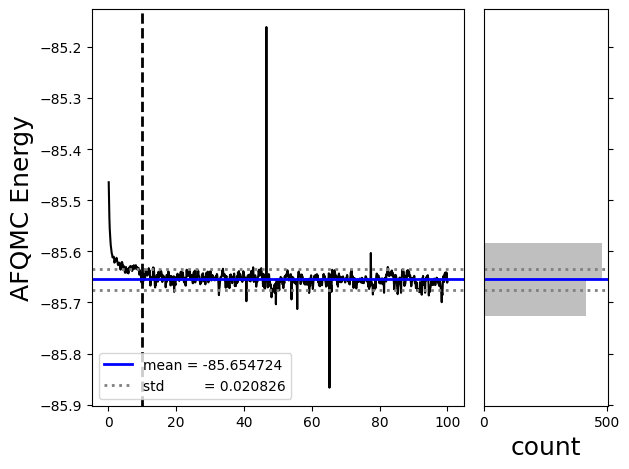

h = 3.893
E = -2330.7856463121734 eV
dE = 0.0287858801507038 eV
E_rhf = -2323.9436016564987 eV
correlation E = -6.842044655674894


In [3]:
o_atom_heights = [ 1.247, 1.436, 1.814, 2.381, 3.326, 3.893]

Ro = 3.8 # Bohr
Rv = 6.2 # Bohr

def save_results(f,label,data):
    data = np.array(data)
    if label in f:
        del f[label]
    dset = f.create_dataset(label, data=data)

rhf_rdm = None
E_rhf_list = []
rhf_rdm_list = []
E_list = []
dE_list = []
for h in o_atom_heights:
    E,dE,Erhf,rhf_rdm = get_afqmc_energy(h=h,Ro=Ro,Rv=Rv,N_energetic_core=1,rhf_guess_rdm=rhf_rdm)
    E_list.append(E)
    dE_list.append(dE)
    E_rhf_list.append(Erhf)
    rhf_rdm_list.append(rhf_rdm)
    print(f"h = {h}")
    print(f"E = {E*Hartree} eV")
    print(f"dE = {dE*Hartree} eV")
    print(f"E_rhf = {Erhf*Hartree} eV")
    print(f"correlation E = {(E - Erhf)*Hartree}")

    with h5.File(scratch_dir / "afqmc_results.h5", "a") as f:
        save_results(f, "h", data=o_atom_heights)
        save_results(f, "E", data=E_list)
        save_results(f, "dE", data=dE_list)
        save_results(f, "E_rhf", data=E_rhf_list)
        save_results(f, "rhf_rdms", data=rhf_rdm_list)

Now, let's plot the resulting energies


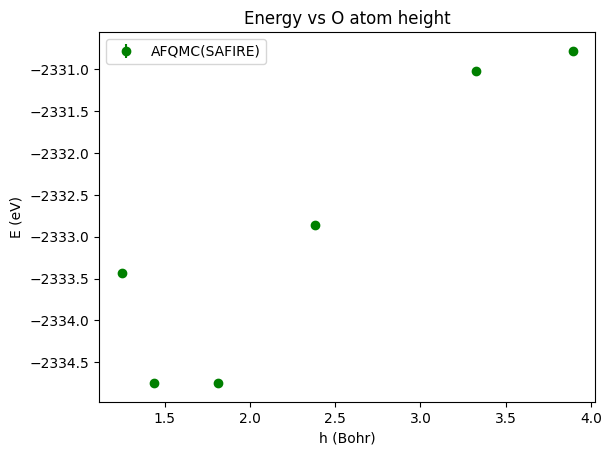

In [4]:
# read results from file to allow saving / re-analysis.
with h5.File(scratch_dir / "afqmc_results.h5", "r") as f:
    o_atom_heights = f["h"][:]
    E_list = f["E"][:]
    dE_list = f["dE"][:]
    E_rhf_list = f["E_rhf"][:]
    rhf_rdm_list = f["rhf_rdms"][:]

# simple plot with no fit
plt.errorbar(o_atom_heights, np.array(E_list)*Hartree, yerr=np.array(dE_list)*Hartree, fmt='o', color='green', label='AFQMC(SAFIRE)')

plt.legend()
plt.xlabel('h (Bohr)')
plt.ylabel('E (eV)')
plt.title('Energy vs O atom height')
plt.savefig(scratch_dir / "energy_vs_height.png")
plt.show()

We can also perform a Morse fit to the AFQMC results using standard Python libraries and some simple functions.
In the code block below, we use bootstrapping to determine the stochastic
uncertainty of the Morse fit parameters.

In [5]:

from scipy.optimize import curve_fit

def morse_potential(r, D, a, r0, D0):
    """
    Morse potential function.

    .. math::

        V(r) = D(1 - e^{-a(r - r0)})^2 + D0

    where

    D: well depth
    a: width of the potential
    r0: equilibrium bond length
    D0: offset of the potential

    Parameters
    ----------
    r : array_like
        Distance from the equilibrium position.
    D : float
        Well depth of the potential.
    a : float
        Width of the potential.
    r0 : float
        Equilibrium bond length.
    D0 : float
        Offset of the potential.

    Returns
    -------
    array_like
        The Morse potential evaluated at distance `r`.
    """
    return D * (1 - np.exp(-a * (r - r0)))**2 + D0

def boostrap_curve_fit(f, x, y, dy, nboostrap_samples=100, **kwargs):
    """
    This function uses bootstrap resampling to estimate the uncertainty in the fit parameters.
    """

    opt_params_list = []

    for i in range(nboostrap_samples):
        # get random data from a guassian distribution with mean y and standard deviation dy
        y_sample = np.random.normal(loc=y, scale=dy)

        # fit the morse potential to the sampled data
        opt_params, _ = curve_fit(f, x, y_sample, **kwargs)
        opt_params_list.append(opt_params)

    mean_opt_params = np.mean(opt_params_list, axis=0)
    std_dev_opt_params = np.std(opt_params_list, axis=0)
    std_error_opt_params = std_dev_opt_params / np.sqrt(nboostrap_samples)


    return mean_opt_params, std_dev_opt_params, std_error_opt_params


AFQMC (literature) Fitted parameters: 
D=4.7124800405600835 +/-  0.002113835466827862
a=1.4241640823615467 +/- 0.0008974988759471164, r0=1.5755411661527987 +/- 0.00015836306428413071, D0=-2334.8958668483597 +/- 0.0009763724512109731
AFQMC fitted parameters: 
D=4.74460823587648 +/- 0.17527886285091485
a=1.3924562944256649 +/- 0.08083922910378337, r0=1.5768671854921024 +/- 0.013291786949951092, D0=-2335.0347558901203 +/- 0.09602498384040721


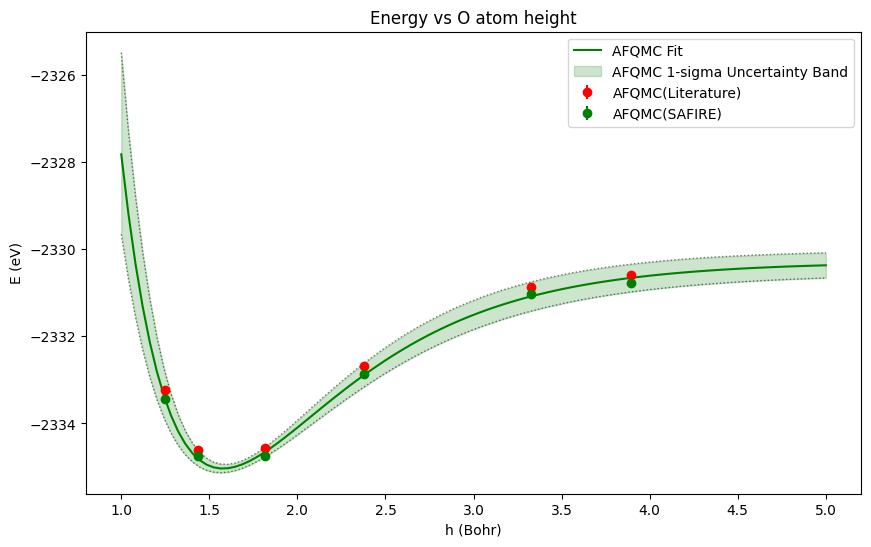

In [6]:
# read results from file to allow saving / re-analysis.
with h5.File(scratch_dir / "afqmc_results.h5", "r") as f:
    o_atom_heights = f["h"][:]
    E_list = f["E"][:]
    dE_list = f["dE"][:]
    E_rhf_list = f["E_rhf"][:]
    rhf_rdm_list = f["rhf_rdms"][:]

o_atom_heights_ref = np.array([1.247,1.436,1.814,2.381,3.326,3.893]) # Bohr
E_ref = np.array([-2333.238,-2334.615,-2334.563,-2332.685,-2330.862,-2330.586]) # eV
dE_ref = np.array([0.011,0.011,0.014,0.017,0.019,0.019]) # eV

# curve fit the reference data
popt_mean, popt_stddev, popt_stderr  = boostrap_curve_fit(
    morse_potential,
    o_atom_heights_ref,
    E_ref,
    dE_ref,
    p0=[4.5, 1.0, 1.6, np.min(E_ref)]
)

print(f"AFQMC (literature) Fitted parameters: \nD={popt_mean[0]} +/-  {popt_stderr[0]}")
print(
    f"a={popt_mean[1]} +/- {popt_stderr[1]}"
    f", r0={popt_mean[2]} +/- {popt_stderr[2]}"
    f", D0={popt_mean[3]} +/- {popt_stderr[3]}"
)

# plot the reference data and the fitted curve
x_fit = np.linspace(1.0, 5.0, 100)
y_fit = morse_potential(x_fit, *popt_mean)
plt.figure(figsize=(10, 6))
plt.errorbar(o_atom_heights_ref, E_ref, yerr=dE_ref, fmt='o', color='red', label='AFQMC(Literature)')
#plt.plot(x_fit, y_fit, label='Fitted Morse Potential', color='red')
plt.title('Morse Potential Fit to O Atom Height Data')


# plot the 1-sigma uncertainty band
y_fit_upper = morse_potential(x_fit, *(popt_mean + popt_stderr))
y_fit_lower = morse_potential(x_fit, *(popt_mean - popt_stderr))

plt.errorbar(o_atom_heights, np.array(E_list)*Hartree, yerr=np.array(dE_list)*Hartree, fmt='o', color='green', label='AFQMC(SAFIRE)')

# fit and plot the AFQMC data
popt_afqmc, pcov_afqmc = curve_fit(
    morse_potential,
    o_atom_heights,
    np.array(E_list)*Hartree,
    sigma=np.array(dE_list)*Hartree,
    p0=[4.5, 1.0, 1.6, np.min(E_list)*Hartree]
)
print(f"AFQMC fitted parameters: \nD={popt_afqmc[0]} +/- {np.sqrt(pcov_afqmc[0,0])}")
print(
    f"a={popt_afqmc[1]} +/- {np.sqrt(pcov_afqmc[1,1])}"
    f", r0={popt_afqmc[2]} +/- {np.sqrt(pcov_afqmc[2,2])}"
    f", D0={popt_afqmc[3]} +/- {np.sqrt(pcov_afqmc[3,3])}"
)
y_fit_afqmc = morse_potential(x_fit, *popt_afqmc)
plt.plot(x_fit, y_fit_afqmc, label='AFQMC Fit', color='green')
# plot the 1-sigma uncertainty band for AFQMC
y_fit_afqmc_upper = morse_potential(x_fit, *(popt_afqmc + np.sqrt(np.diag(pcov_afqmc))))
y_fit_afqmc_lower = morse_potential(x_fit, *(popt_afqmc - np.sqrt(np.diag(pcov_afqmc))))
plt.fill_between(x_fit, y_fit_afqmc_lower, y_fit_afqmc_upper, color='green', alpha=0.2, label='AFQMC 1-sigma Uncertainty Band')

plt.plot(x_fit, y_fit_afqmc_lower, ':', color='black', alpha=0.5, linewidth=1)
plt.plot(x_fit, y_fit_afqmc_upper, ':', color='black', alpha=0.5, linewidth=1)

plt.legend()
plt.xlabel('h (Bohr)')
plt.ylabel('E (eV)')
plt.title('Energy vs O atom height')
plt.savefig(scratch_dir / "energy_vs_height.png")
plt.show()